# Trader Performance vs Market Sentiment Analysis

This project analyzes the relationship between cryptocurrency market sentiment
(Fear vs Greed) and trader behavior using Hyperliquid trading data.

Objective:
- Analyze how trader performance changes with market sentiment
- Study behavioral differences during Fear vs Greed periods
- Extract insights that could inform trading strategies

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [41]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")


In [42]:
sentiment.head()
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Dataset Overview


In [43]:
sentiment.shape
trades.shape

(211224, 16)

In [44]:
sentiment.columns
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [45]:
sentiment.isnull().sum()
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [46]:
sentiment.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

In [47]:
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

## Data Cleaning and Preparation

In [48]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [49]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])
data = pd.merge(trades, sentiment, on='date', how='left')

In [50]:
data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


## Feature Engineering

In [51]:
data['win'] = data['Closed PnL'] > 0

In [52]:
data['segment'] = data['Size USD'].apply(
    lambda x: 'High Volume' if x > 10000 else 'Low Volume'
)

## Market Sentiment vs Trader Performance

## Market Sentiment vs Trader Performance

In [53]:
daily_pnl = data.groupby(['date','classification'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,date,classification,Closed PnL
0,2023-05-01,Greed,0.000000
1,2023-12-05,Extreme Greed,0.000000
2,2023-12-14,Greed,-205.434737
3,2023-12-15,Greed,-24.632034
4,2023-12-16,Greed,0.000000


In [54]:
data.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


In [55]:
data.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


## Data Visualization

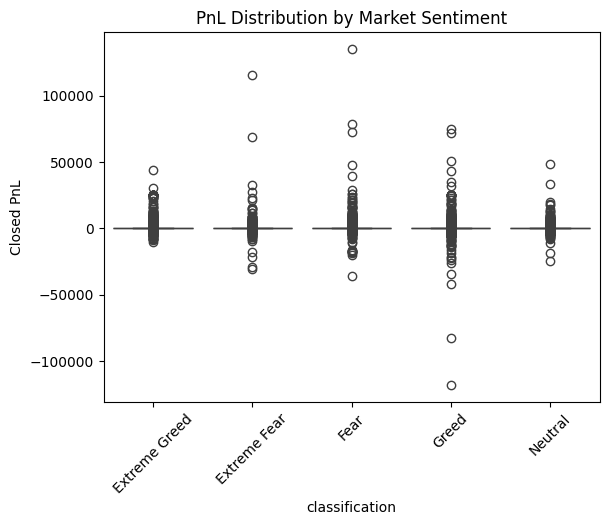

In [56]:
sns.boxplot(x='classification', y='Closed PnL', data=data)
plt.xticks(rotation=45)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

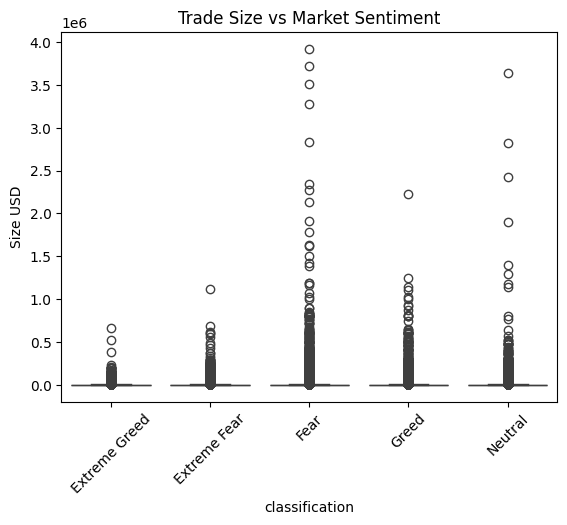

In [57]:
sns.boxplot(x='classification', y='Size USD', data=data)
plt.xticks(rotation=45)
plt.title("Trade Size vs Market Sentiment")
plt.show()

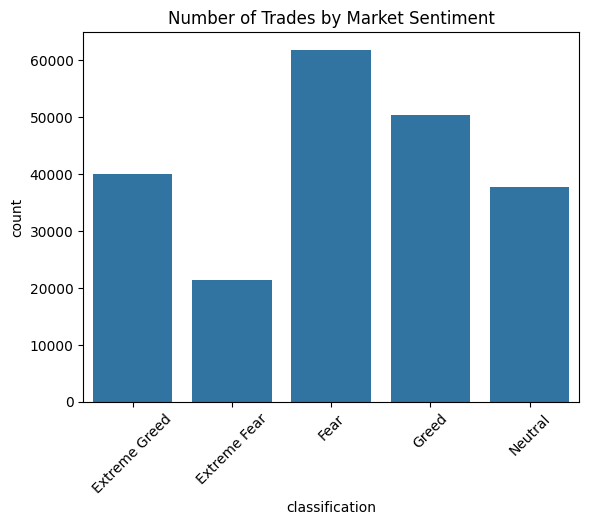

In [58]:
sns.countplot(x='classification', data=data)
plt.xticks(rotation=45)
plt.title("Number of Trades by Market Sentiment")
plt.show()

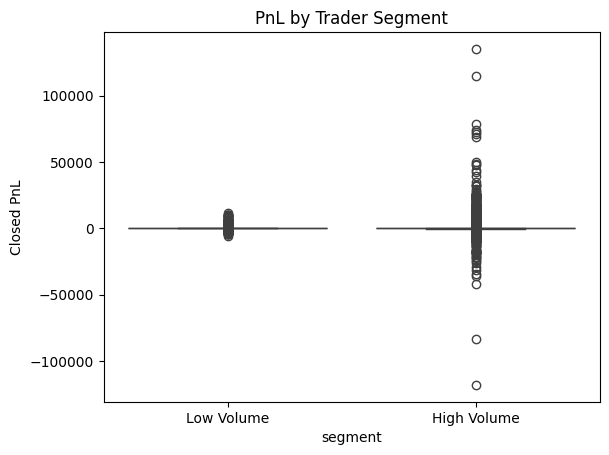

In [59]:
sns.boxplot(x='segment', y='Closed PnL', data=data)
plt.title("PnL by Trader Segment")
plt.show()

## Key Insights

1. Traders tend to increase position sizes during Greed periods.

2. Profit volatility appears higher during Fear and Extreme Fear periods.

3. High-volume traders generate higher profits but also experience larger losses.

## Strategy Recommendations

Strategy 1:
During Extreme Fear periods traders should reduce position size to manage risk.

Strategy 2:
During Greed periods traders may increase trading frequency but limit leverage.

## Conclusion

This analysis shows that market sentiment influences trader behavior and
performance. Greed periods often lead to larger trade sizes while Fear periods
increase volatility. These insights can help traders adjust their strategies
based on market conditions.